In [719]:
import pandas as pd

In [720]:
import matplotlib.pyplot as plt

In [721]:
import numpy as np

In [773]:
import joblib

In [722]:
df = pd.read_csv('heart_disease_combined_4centers.csv')
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,cleveland
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,cleveland
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,cleveland
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,cleveland
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,cleveland


Data Cleanning

In [723]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
 14  source    920 non-null    str    
dtypes: float64(13), int64(1), str(1)
memory usage: 107.9 KB


In [724]:
columens =['ca' , 'thal' , 'slope']

for col in columens:
    df[col] = df[ col ].fillna("Missing Data")

In [725]:
delete_source = df.pop("source")

In [726]:
df['chol']


0      233.0
1      286.0
2      229.0
3      250.0
4      204.0
       ...  
915    331.0
916    294.0
917    342.0
918    393.0
919    275.0
Name: chol, Length: 920, dtype: float64

In [727]:
df.loc[df["chol"] == 0, "chol"] = np.nan

In [728]:
df['chol'].isnull().sum()

np.int64(202)

In [729]:
df = df.dropna()

In [730]:
dtypes = ['sex' , 'age' , 'cp' , 'trestbps' ,'restecg']
for col  in dtypes:
    df[col] = df[col].astype('Int64')

In [731]:
df['target']= df['target'].astype('bool')
df['fbs'] =df['fbs'].astype('bool')
df['exang'] =df['exang'].astype('bool')

In [732]:
df.info()

<class 'pandas.DataFrame'>
Index: 661 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       661 non-null    Int64  
 1   sex       661 non-null    Int64  
 2   cp        661 non-null    Int64  
 3   trestbps  661 non-null    Int64  
 4   chol      661 non-null    float64
 5   fbs       661 non-null    bool   
 6   restecg   661 non-null    Int64  
 7   thalach   661 non-null    float64
 8   exang     661 non-null    bool   
 9   oldpeak   661 non-null    float64
 10  slope     661 non-null    object 
 11  ca        661 non-null    object 
 12  thal      661 non-null    object 
 13  target    661 non-null    bool   
dtypes: Int64(5), bool(3), float64(3), object(3)
memory usage: 67.1+ KB


In [733]:
df.value_counts('target')

target
False    347
True     314
Name: count, dtype: int64

In [734]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233.0,True,2,150.0,False,2.3,3.0,0.0,6.0,False
1,67,1,4,160,286.0,False,2,108.0,True,1.5,2.0,3.0,3.0,True
2,67,1,4,120,229.0,False,2,129.0,True,2.6,2.0,2.0,7.0,True
3,37,1,3,130,250.0,False,0,187.0,False,3.5,3.0,0.0,3.0,False
4,41,0,2,130,204.0,False,2,172.0,False,1.4,1.0,0.0,3.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,52,1,4,160,331.0,False,0,94.0,True,2.5,Missing Data,Missing Data,Missing Data,True
916,54,0,3,130,294.0,False,1,100.0,True,0.0,2.0,Missing Data,Missing Data,True
917,56,1,4,155,342.0,True,0,150.0,True,3.0,2.0,Missing Data,Missing Data,True
918,58,0,2,180,393.0,False,0,110.0,True,1.0,2.0,Missing Data,7.0,True


age and sex analyze

In [735]:
df.loc[(df["target"]==1) & (df["age"]>= 45)& (df["sex"]==1) ]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,67,1,4,160,286.0,False,2,108.0,True,1.5,2.0,3.0,3.0,True
2,67,1,4,120,229.0,False,2,129.0,True,2.6,2.0,2.0,7.0,True
8,63,1,4,130,254.0,False,2,147.0,False,1.4,2.0,1.0,7.0,True
9,53,1,4,140,203.0,True,2,155.0,True,3.1,3.0,0.0,7.0,True
12,56,1,3,130,256.0,True,2,142.0,True,0.6,2.0,1.0,6.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,50,1,4,140,341.0,False,1,125.0,True,2.5,2.0,Missing Data,Missing Data,True
914,52,1,4,140,266.0,False,0,134.0,True,2.0,2.0,Missing Data,Missing Data,True
915,52,1,4,160,331.0,False,0,94.0,True,2.5,Missing Data,Missing Data,Missing Data,True
917,56,1,4,155,342.0,True,0,150.0,True,3.0,2.0,Missing Data,Missing Data,True


In [736]:
df.loc[(df["target"]==1) & (df["age"]<45)& (df["sex"]==1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
29,40,1,4,110,167.0,False,2,114.0,True,2.0,2.0,0.0,7.0,True
36,43,1,4,120,177.0,False,2,120.0,True,2.5,2.0,0.0,7.0,True
52,44,1,4,112,290.0,False,2,153.0,False,0.0,1.0,1.0,3.0,True
57,41,1,4,110,172.0,False,2,158.0,False,0.0,1.0,0.0,7.0,True
74,44,1,4,110,197.0,False,2,177.0,False,0.0,1.0,1.0,3.0,True
109,39,1,4,118,219.0,False,0,140.0,False,1.2,2.0,0.0,7.0,True
138,35,1,4,120,198.0,False,0,130.0,True,1.6,2.0,0.0,7.0,True
168,35,1,4,126,282.0,False,2,156.0,True,0.0,1.0,0.0,7.0,True
192,43,1,4,132,247.0,True,2,143.0,True,0.1,2.0,Missing Data,7.0,True
211,38,1,1,120,231.0,False,0,182.0,True,3.8,2.0,0.0,7.0,True


In [737]:
df.loc[(df['target']==1)&(df["sex"]==0)&(df["age"]>=55)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
6,62,0,4,140,268.0,False,2,160.0,False,3.6,3.0,2.0,3.0,True
40,65,0,4,150,225.0,False,2,114.0,False,1.0,2.0,3.0,7.0,True
44,61,0,4,130,330.0,False,2,169.0,False,0.0,1.0,0.0,3.0,True
91,62,0,4,160,164.0,False,2,145.0,False,6.2,3.0,3.0,7.0,True
97,60,0,4,150,258.0,False,2,157.0,False,2.6,2.0,2.0,7.0,True
110,61,0,4,145,307.0,False,2,146.0,True,1.0,2.0,0.0,7.0,True
114,62,0,3,130,263.0,False,0,97.0,False,1.2,2.0,1.0,7.0,True
121,63,0,4,150,407.0,False,2,154.0,False,4.0,2.0,3.0,7.0,True
126,56,0,4,200,288.0,True,2,133.0,True,4.0,3.0,2.0,7.0,True
172,59,0,4,174,249.0,False,0,143.0,True,0.0,2.0,0.0,3.0,True


In [738]:
df.loc[(df['target']==1)&(df["sex"]==0)&(df["age"]<55)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
60,51,0,4,130,305.0,False,0,142.0,True,1.2,2.0,0.0,7.0,True
113,43,0,4,132,341.0,True,2,136.0,True,3.0,2.0,0.0,7.0,True
552,54,0,4,138,274.0,False,0,105.0,True,1.5,2.0,Missing Data,Missing Data,True
621,54,0,4,127,333.0,True,1,154.0,False,0.0,Missing Data,Missing Data,Missing Data,True
815,33,0,4,100,246.0,False,0,150.0,True,1.0,2.0,Missing Data,Missing Data,True
835,49,0,3,160,180.0,False,0,156.0,False,1.0,2.0,Missing Data,Missing Data,True
838,50,0,3,140,288.0,False,0,140.0,True,0.0,Missing Data,Missing Data,7.0,True
840,51,0,4,160,303.0,False,0,150.0,True,1.0,2.0,Missing Data,Missing Data,True
854,40,0,4,150,392.0,False,0,130.0,False,2.0,2.0,Missing Data,6.0,True
882,47,0,3,135,248.0,True,0,170.0,False,0.0,Missing Data,Missing Data,Missing Data,True


In [739]:
df.describe()

,age,sex,cp,trestbps,chol,restecg,thalach,oldpeak
count,661.0,661.0,661.0,661.0,661.000000,661.0,661.000000,661.000000
mean,52.612708,0.741301,3.175492,132.791225,246.446293,0.65053,141.178517,0.908472
std,9.456027,0.438251,0.954767,17.795862,57.609834,0.86012,25.045260,1.101426
min,28.0,0.0,1.0,92.0,85.000000,0.0,69.000000,0.000000
25%,46.0,0.0,2.0,120.0,210.000000,0.0,123.000000,0.000000
50%,54.0,1.0,4.0,130.0,240.000000,0.0,142.000000,0.500000
75%,59.0,1.0,4.0,140.0,275.000000,2.0,160.000000,1.500000
max,77.0,1.0,4.0,200.0,603.000000,2.0,202.000000,6.200000


In [740]:
numeric_cols = ['age', 'trestbps',  'chol','thalach', 'oldpeak']
df.groupby(['target', 'sex']) [numeric_cols].mean()

age    trestbps        chol     thalach   oldpeak
target sex                                                         
False  0    51.343511  128.389313  247.412214  149.007634  0.444275
       1    49.319444  130.606481  235.601852  150.648148  0.391667
True   0       56.025     143.375  279.175000  139.250000  1.467500
       1    55.317518  135.072993  249.755474  130.251825  1.456204

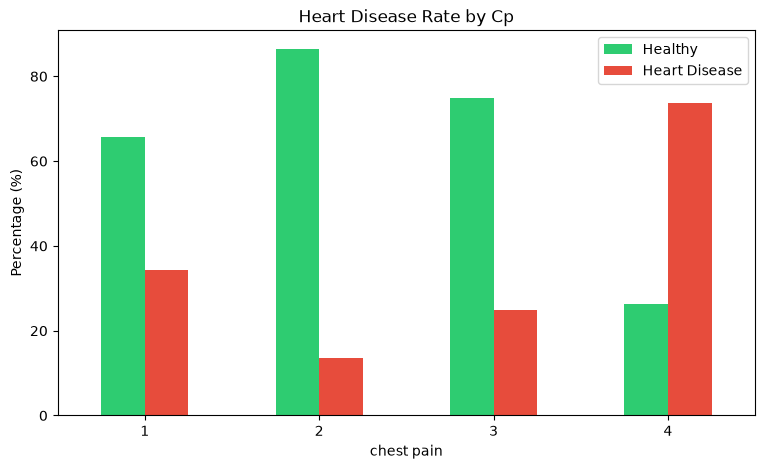

In [741]:
cp_rate = pd.crosstab(df["cp"] , df["target"] , normalize="index")*100

cp_rate.plot(kind="bar" , figsize=(9,5) ,  color=['#2ecc71', '#e74c3c'])
plt.xlabel("chest pain")
plt.ylabel("Percentage (%)")
plt.title("Heart Disease Rate by Cp")
plt.legend(["Healthy","Heart Disease"])
plt.xticks(rotation=0)
plt.show()

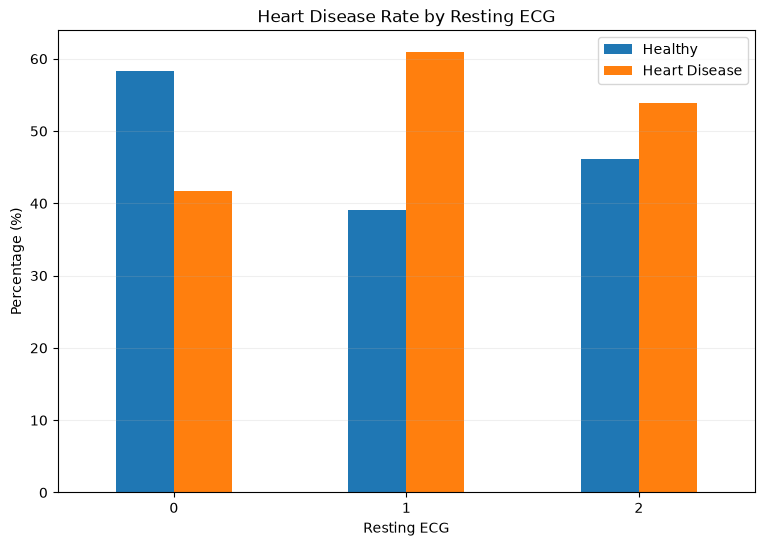

In [742]:
rate =pd.crosstab(df["restecg"], df["target"] , normalize= "index")*100

rate.plot(kind= "bar" , figsize=(9,6))
plt.xlabel("Resting ECG")
plt.ylabel("Percentage (%)")
plt.title("Heart Disease Rate by Resting ECG")
plt.xticks(rotation=0)
plt.legend(["Healthy","Heart Disease"])
plt.grid(axis="y" , alpha= 0.2)

In [743]:
df.groupby(['target','sex'])[numeric_cols].std()

age   trestbps       chol    thalach   oldpeak
target sex                                                     
False  0    9.869745  16.439901  60.718882  21.976035  0.629060
       1    9.025792  16.368369  49.559819  24.240967  0.730355
True   0    7.187908  20.658006  60.106268  21.698103  1.391437
       1     8.93554  18.172811  59.633822  23.145473  1.177342

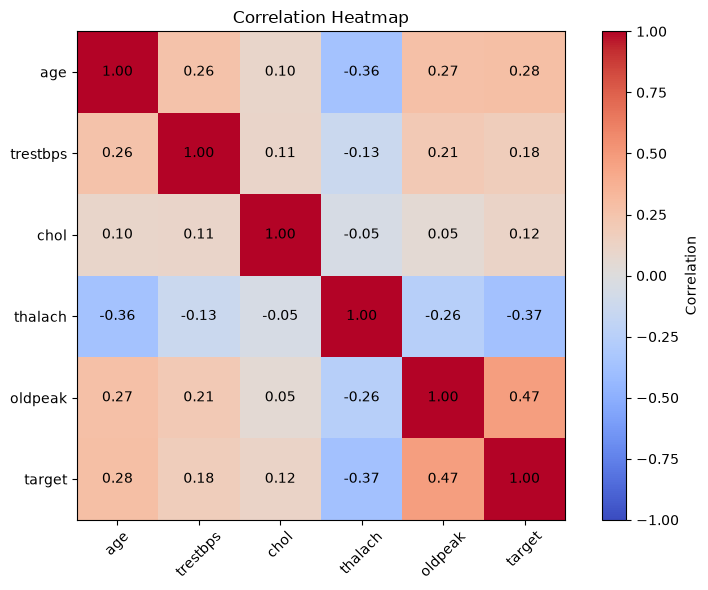

In [744]:
numeric_for_corr = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_corr = df[numeric_for_corr].copy()
df_corr['target'] = df['target'].astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', color='black')

plt.colorbar(im, label='Correlation')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [745]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df.groupby(col)['target'].mean())
    print()

--- sex ---
sex
0    0.233918
1    0.559184
Name: target, dtype: float64

--- cp ---
cp
1    0.342857
2    0.135135
3    0.250000
4    0.736527
Name: target, dtype: float64

--- fbs ---
fbs
False    0.446619
True     0.636364
Name: target, dtype: float64

--- restecg ---
restecg
0    0.417500
1    0.608696
2    0.538462
Name: target, dtype: float64

--- exang ---
exang
False    0.279126
True     0.799197
Name: target, dtype: float64

--- slope ---
slope
1.0             0.273292
2.0             0.718147
3.0             0.738095
Missing Data    0.266332
Name: target, dtype: float64



Exercise Test

In [746]:
exercise_thalach = ['age','thalach']
df.groupby(['target'])[exercise_thalach].agg(['median' ,'mean' ,'std'])

age                      thalach                       
       median       mean       std  median        mean        std
target                                                           
False    51.0  50.083573  9.390774   152.0  150.028818  23.392956
True     56.0  55.407643  8.725458   130.0  131.398089  23.128840

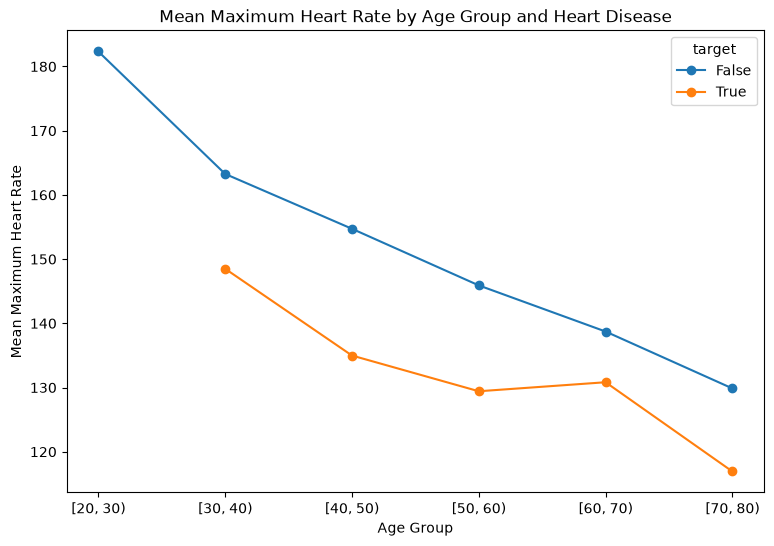

In [747]:
df['age_group'] = pd.cut(df["age"], bins=[20,30,40,50,60,70,80] , right= False)

mean_thalach = df.groupby(['age_group' ,'target'], observed= True)["thalach"].mean().unstack()

mean_thalach.plot(marker= 'o', figsize=(9,6))
plt.xlabel("Age Group")
plt.ylabel("Mean Maximum Heart Rate")
plt.title("Mean Maximum Heart Rate by Age Group and Heart Disease")

plt.show()

In [748]:
test =['exang','oldpeak']
df.groupby(['target'])[test].sum()

,exang,oldpeak
target,,
False,50,142.8
True,199,457.7


In [749]:
pd.crosstab( df['slope'],  df['target'] , normalize= 'columns')

target,False,True
slope,,
1.0,0.337176,0.140127
2.0,0.210375,0.592357
3.0,0.031700,0.098726
Missing Data,0.420749,0.168790


In [750]:
pd.crosstab(df['target'], df['slope'])

slope,1.0,2.0,3.0,Missing Data
target,,,,
False,117,73,11,146
True,44,186,31,53


Thal test and Coronary Artery

In [751]:
TCA_test = ["thal" , "ca"]
for I in TCA_test:
    print(f"--- {I} ---")
    print(df.groupby(I)["target"].mean())
    print()

--- thal ---
thal
3.0             0.217143
6.0             0.696970
7.0             0.757143
Missing Data    0.469649
Name: target, dtype: float64

--- ca ---
ca
0.0             0.268156
1.0             0.676923
2.0             0.815789
3.0             0.850000
Missing Data    0.484680
Name: target, dtype: float64



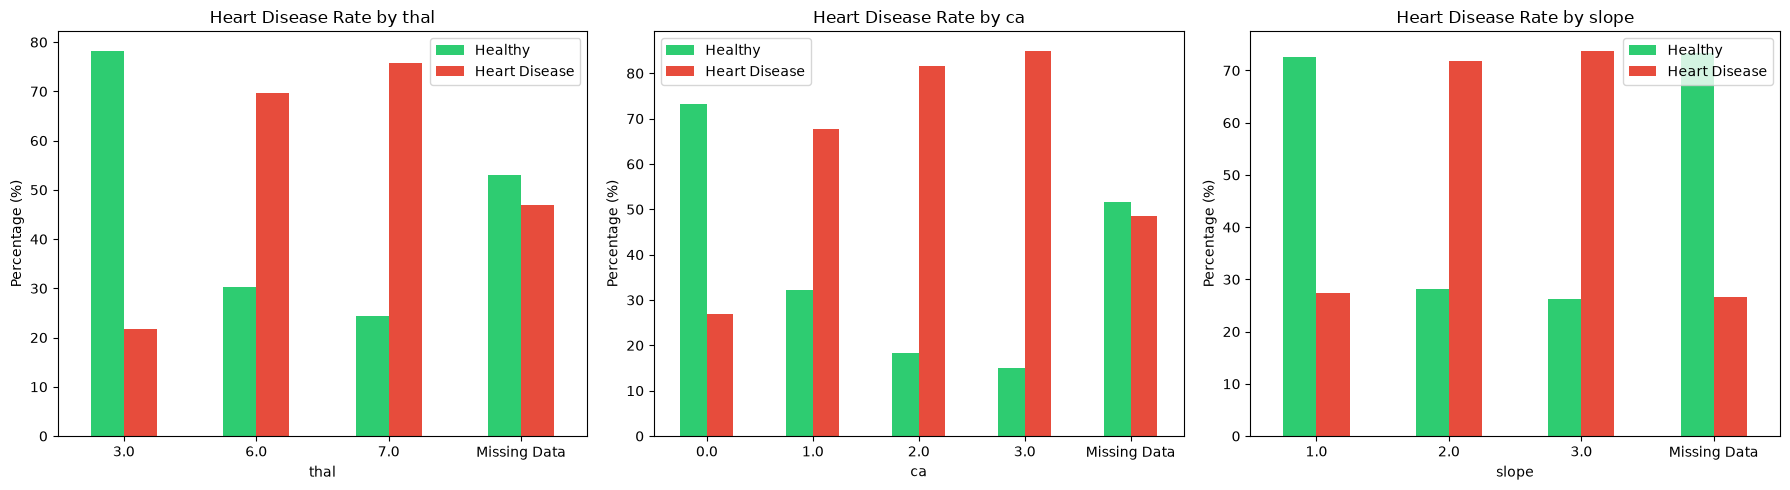

In [752]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_plot = ['thal', 'ca', 'slope']

for ax, feature in zip(axes, features_to_plot):
    rate = pd.crosstab(df[feature], df["target"], normalize="index") * 100
    rate.plot(kind="bar", ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_xlabel(feature)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Heart Disease Rate by {feature}")
    ax.legend(["Healthy", "Heart Disease"])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [753]:
categorical_to_encode = ['cp' , 'thal','ca' , 'slope' , 'restecg']
df_encoded = pd.get_dummies(df , columns=categorical_to_encode , drop_first= True)
df_encoded

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,age_group,...,thal_Missing Data,ca_1.0,ca_2.0,ca_3.0,ca_Missing Data,slope_2.0,slope_3.0,slope_Missing Data,restecg_1,restecg_2
0,63,1,145,233.0,True,150.0,False,2.3,False,"[60, 70)",...,False,False,False,False,False,False,True,False,False,True
1,67,1,160,286.0,False,108.0,True,1.5,True,"[60, 70)",...,False,False,False,True,False,True,False,False,False,True
2,67,1,120,229.0,False,129.0,True,2.6,True,"[60, 70)",...,False,False,True,False,False,True,False,False,False,True
3,37,1,130,250.0,False,187.0,False,3.5,False,"[30, 40)",...,False,False,False,False,False,False,True,False,False,False
4,41,0,130,204.0,False,172.0,False,1.4,False,"[40, 50)",...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,52,1,160,331.0,False,94.0,True,2.5,True,"[50, 60)",...,True,False,False,False,True,False,False,True,False,False
916,54,0,130,294.0,False,100.0,True,0.0,True,"[50, 60)",...,True,False,False,False,True,True,False,False,True,False
917,56,1,155,342.0,True,150.0,True,3.0,True,"[50, 60)",...,True,False,False,False,True,True,False,False,False,False
918,58,0,180,393.0,False,110.0,True,1.0,True,"[50, 60)",...,False,False,False,False,True,True,False,False,False,False


In [754]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop(columns=['target' , 'age_group'])
y = df_encoded['target']

X_train ,X_test , y_train , y_test = train_test_split( x , y ,test_size= 0.2, random_state=42 , stratify=y)
print('X_train shape : ', X_train.shape)
print('x_test shape : ', X_test.shape)
print()
print('class distribution in train : ')
print(y_train.value_counts(normalize= True)*100)
print()
print('class distribution in test : ')
print(y_test.value_counts(normalize= True)*100)

X_train shape :  (528, 23)
x_test shape :  (133, 23)

class distribution in train : 
target
False    52.462121
True     47.537879
Name: proportion, dtype: float64

class distribution in test : 
target
False    52.631579
True     47.368421
Name: proportion, dtype: float64


In [755]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['age' , 'trestbps' , 'chol' , 'thalach' , 'oldpeak']

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.fit_transform(X_test[numeric_features])

print(X_train[numeric_features].describe)

<bound method NDFrame.describe of           age  trestbps      chol   thalach   oldpeak
29  -1.339883 -1.287114 -1.385436 -1.120391  1.031436
117 -1.867207  0.320447 -1.112854  1.623198  0.472778
31   0.769414 -0.885224 -0.312141  0.735567  0.472778
752 -0.074305 -0.138857 -1.163963 -0.071371  0.565888
736 -0.285234 -0.712985  1.357430 -1.281778  0.100340
..        ...       ...       ...       ...       ...
544  0.663949 -0.425921 -0.448433 -0.273106  1.496985
86  -0.601629  0.320447  0.147843  0.574179 -0.830757
886 -0.179770  0.148208 -1.504692  0.332098  1.031436
105  0.136625 -1.401940  1.033737  0.574179 -0.830757
428  0.769414 -0.024031 -0.516578 -0.071371  0.565888

[528 rows x 5 columns]>


In [756]:
print(X_train.dtypes)

age                   float64
sex                     Int64
trestbps              float64
chol                  float64
fbs                      bool
thalach               float64
exang                    bool
oldpeak               float64
cp_2                     bool
cp_3                     bool
cp_4                     bool
thal_6.0                 bool
thal_7.0                 bool
thal_Missing Data        bool
ca_1.0                   bool
ca_2.0                   bool
ca_3.0                   bool
ca_Missing Data          bool
slope_2.0                bool
slope_3.0                bool
slope_Missing Data       bool
restecg_1                bool
restecg_2                bool
dtype: object


In [757]:
from sklearn.linear_model import  LogisticRegression

log_reg = LogisticRegression(random_state=42 , max_iter=1000)

log_reg.fit(X_train , y_train)
y_pred = log_reg.predict(X_test)

print("predict :", y_pred[:10])
print("real answer:" , y_test[:10].values)

predict : [ True  True  True False False False False  True False  True]
real answer: [ True False  True False False False False False False  True]


In [758]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# دقت کلی
print("Accuracy:", accuracy_score(y_test, y_pred))
print()

# گزارش کامل (Precision, Recall, F1)
print(classification_report(y_test, y_pred))
print()

# ماتریس درهم‌ریختگی
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

# ROC-AUC (نیاز به احتمال داره، نه فقط پیش‌بینی نهایی)
y_proba = log_reg.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7969924812030075

              precision    recall  f1-score   support

       False       0.81      0.80      0.81        70
        True       0.78      0.79      0.79        63

    accuracy                           0.80       133
   macro avg       0.80      0.80      0.80       133
weighted avg       0.80      0.80      0.80       133


Confusion Matrix:
[[56 14]
 [13 50]]

ROC-AUC: 0.9204081632653061


In [759]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score

print("Accuracy : " , accuracy_score(y_test , y_pred) )
print()

print(classification_report(y_test , y_pred))
print()

print("confusion matrix : ")
print(confusion_matrix(y_test , y_pred))
print()

y_proba = log_reg.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy :  0.7969924812030075

              precision    recall  f1-score   support

       False       0.81      0.80      0.81        70
        True       0.78      0.79      0.79        63

    accuracy                           0.80       133
   macro avg       0.80      0.80      0.80       133
weighted avg       0.80      0.80      0.80       133


confusion matrix : 
[[56 14]
 [13 50]]

ROC-AUC: 0.9204081632653061


In [760]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ساخت مدل
dt = DecisionTreeClassifier(random_state=42, max_depth=5)

# آموزش
dt.fit(X_train, y_train)

# پیش‌بینی
y_pred_dt = dt.predict(X_test)

# ارزیابی
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7819548872180451


              precision    recall  f1-score   support

       False       0.77      0.83      0.80        70
        True       0.79      0.73      0.76        63

    accuracy                           0.78       133
   macro avg       0.78      0.78      0.78       133
weighted avg       0.78      0.78      0.78       133

Confusion Matrix:
[[58 12]
 [17 46]]


Random Forest

In [761]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8195488721804511
              precision    recall  f1-score   support

       False       0.81      0.86      0.83        70
        True       0.83      0.78      0.80        63

    accuracy                           0.82       133
   macro avg       0.82      0.82      0.82       133
weighted avg       0.82      0.82      0.82       133

Confusion Matrix:
[[60 10]
 [14 49]]


XGBoost

In [762]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:52:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8195488721804511
              precision    recall  f1-score   support

       False       0.85      0.80      0.82        70
        True       0.79      0.84      0.82        63

    accuracy                           0.82       133
   macro avg       0.82      0.82      0.82       133
weighted avg       0.82      0.82      0.82       133

Confusion Matrix:
[[56 14]
 [10 53]]


                 Model  Accuracy  Precision (Disease)  Recall (Disease)  \
0  Logistic Regression     0.797                 0.78              0.79   
1        Decision Tree     0.782                 0.79              0.73   
2        Random Forest     0.820                 0.83              0.78   
3              XGBoost     0.820                 0.79              0.84   

   F1 (Disease)  
0          0.79  
1          0.76  
2          0.80  
3          0.82  


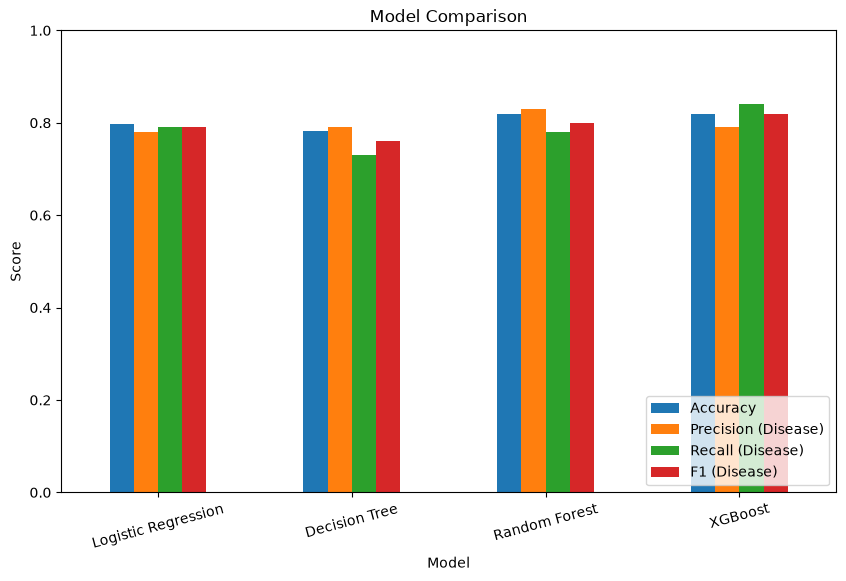

In [763]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.797, 0.782, 0.820, 0.820],
    'Precision (Disease)': [0.78, 0.79, 0.83, 0.79],
    'Recall (Disease)': [0.79, 0.73, 0.78, 0.84],
    'F1 (Disease)': [0.79, 0.76, 0.80, 0.82]
})
print(results)

results.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

Cross-Validation

In [764]:
# سلول تمیز و نهایی - همیشه از اینجا شروع کن
X = df_encoded.drop(columns=['target', 'age_group'])
y = df_encoded['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.preprocessing import StandardScaler
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("X shape:", X.shape)
print("همه‌ی dtype ها:")
print(X.dtypes.value_counts())

X shape: (661, 23)
همه‌ی dtype ها:
bool       17
Int64       3
float64     3
Name: count, dtype: int64


In [765]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: میانگین = {scores.mean():.3f}, انحراف‌معیار = {scores.std():.3f}")

C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t

Logistic Regression: میانگین = 0.803, انحراف‌معیار = 0.041
Decision Tree: میانگین = 0.749, انحراف‌معیار = 0.038
Random Forest: میانگین = 0.802, انحراف‌معیار = 0.021


C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:52:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:52:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AVANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:52:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } 

XGBoost: میانگین = 0.755, انحراف‌معیار = 0.039


In [766]:
print(X.dtypes)

age                     Int64
sex                     Int64
trestbps                Int64
chol                  float64
fbs                      bool
thalach               float64
exang                    bool
oldpeak               float64
cp_2                     bool
cp_3                     bool
cp_4                     bool
thal_6.0                 bool
thal_7.0                 bool
thal_Missing Data        bool
ca_1.0                   bool
ca_2.0                   bool
ca_3.0                   bool
ca_Missing Data          bool
slope_2.0                bool
slope_3.0                bool
slope_Missing Data       bool
restecg_1                bool
restecg_2                bool
dtype: object


GridSearchCV

In [767]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("بهترین پارامترها:", grid_search.best_params_)
print("بهترین دقت (روی Cross-Validation):", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print()
print("Accuracy روی test نهایی:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

بهترین پارامترها: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
بهترین دقت (روی Cross-Validation): 0.8238814016172507

Accuracy روی test نهایی: 0.8345864661654135
              precision    recall  f1-score   support

       False       0.83      0.86      0.85        70
        True       0.84      0.81      0.82        63

    accuracy                           0.83       133
   macro avg       0.83      0.83      0.83       133
weighted avg       0.83      0.83      0.83       133



In [768]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\AVANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


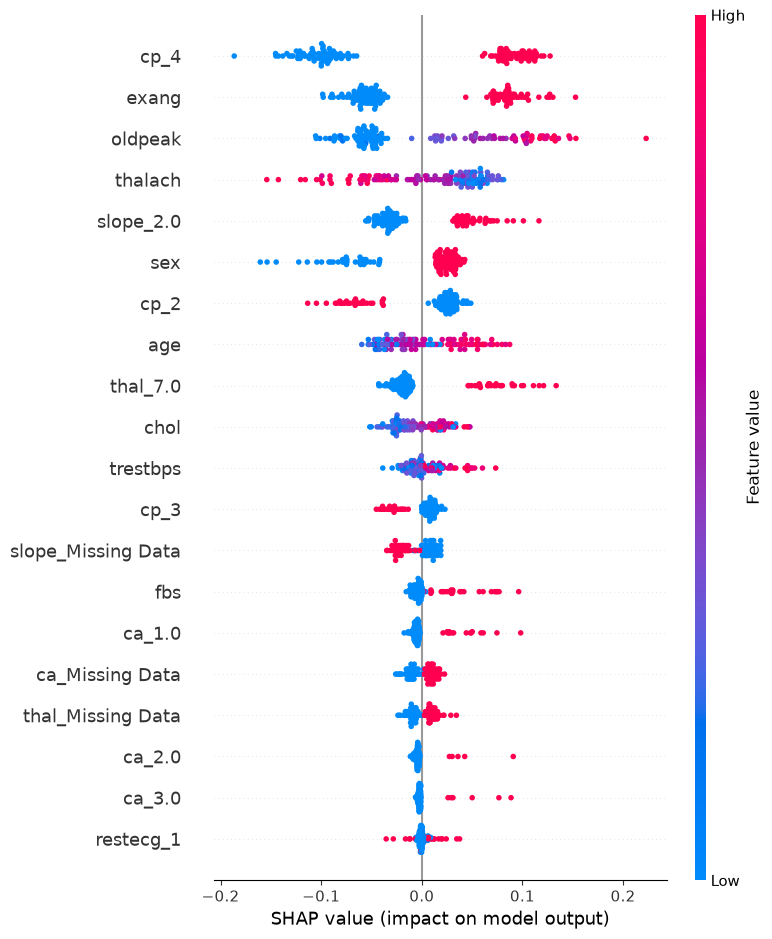

In [769]:
import shap

# ساخت Explainer مخصوص مدل‌های درختی (سریع‌تر از روش عمومی)
explainer = shap.TreeExplainer(best_rf)

# محاسبه‌ی SHAP values برای داده‌ی تست
shap_values = explainer.shap_values(X_test)

# نمودار خلاصه: مهم‌ترین فیچرها در کل مدل
shap.summary_plot(shap_values[:,:,1], X_test)

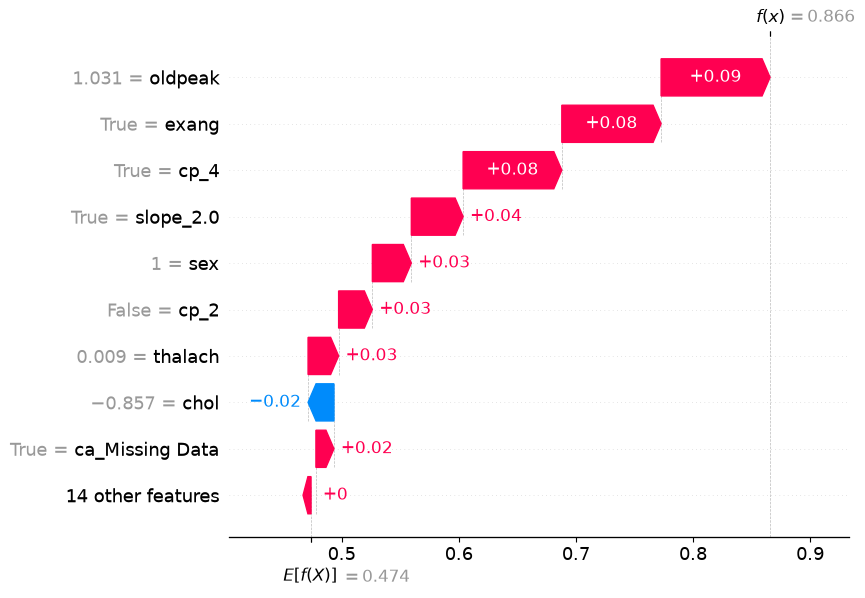

In [ ]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

sample_index = 0

shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[sample_index],
    feature_names=X_test.columns.tolist()
))

In [772]:
%pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\AVANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [774]:

joblib.dump(best_rf, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

print("ذخیره شد ✅")

ذخیره شد ✅


In [775]:
feature_columns = joblib.load('feature_columns.pkl')
print(feature_columns)

['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2', 'cp_3', 'cp_4', 'thal_6.0', 'thal_7.0', 'thal_Missing Data', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'ca_Missing Data', 'slope_2.0', 'slope_3.0', 'slope_Missing Data', 'restecg_1', 'restecg_2']
